In [1]:
%matplotlib inline
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook lives in data/; the Django project (and checker/logic.py) is one level up.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name in ("data_sonney", "data") else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import checker.logic as checker_logic
from checker.logic import VALID_CLASSES

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (8, 4.5)

print("Algorithm loaded from:", (PROJECT_ROOT / "checker" / "logic.py").resolve())
print("VALID_CLASSES:", VALID_CLASSES)


Algorithm loaded from: C:\Users\cisnl\Desktop\sonney_system\beneficiary\checker\logic.py
VALID_CLASSES: ['Solo Parent', 'PWD', 'Senior Citizen', 'Construction Worker', 'Rice Farmer', 'Market Vendor', 'Tricycle Driver', 'Lactating Mother']


## Part 1 — Unit tests for the screening rule

`screen()` below is the eligibility rule used throughout this notebook. It
checks, in order: membership in one of the real `VALID_CLASSES` (imported
from `checker/logic.py`), a grant received within the last 3 months, and a
household member who received one. The hand-picked cases pin down every
branch. They don't touch the registry data at all, so they keep working as a
regression check even if the simulated data in later parts changes.

In [2]:
def screen(beneficiary_class, received_grant_within_3_months, household_blocker_name=None):
    """Return a dict with the screening decision and the reason."""
    if beneficiary_class not in VALID_CLASSES:
        decision, reason = "Not qualified", "Not a member of any valid beneficiary class."
    elif received_grant_within_3_months:
        decision, reason = "Not qualified", "Received a grant within the last 3 months."
    elif household_blocker_name:
        decision, reason = (
            "Not qualified",
            f"A family member ({household_blocker_name}) received a grant "
            f"within the last 3 months.",
        )
    else:
        decision, reason = "Passes screen", "Passes class and grant-history checks."

    return {
        "decision": decision,
        "reason": reason,
        "passes": decision == "Passes screen",
    }

In [3]:
cases = [
    ("invalid class is always rejected",
     dict(beneficiary_class="Barangay Captain", received_grant_within_3_months=False),
     False),
    ("None is rejected as an invalid class",
     dict(beneficiary_class=None, received_grant_within_3_months=False),
     False),
    ("valid class + recent grant -> rejected",
     dict(beneficiary_class="PWD", received_grant_within_3_months=True),
     False),
    ("household blocker rejects even with no personal recent grant",
     dict(beneficiary_class="PWD", received_grant_within_3_months=False,
          household_blocker_name="Juan Dela Cruz"),
     False),
    ("valid class + no recent grant passes",
     dict(beneficiary_class="Senior Citizen", received_grant_within_3_months=False),
     True),
]

failures = 0
for description, kwargs, expected in cases:
    outcome = screen(**kwargs)
    ok = outcome["passes"] == expected
    failures += not ok
    print(f"[{'PASS' if ok else 'FAIL'}] {description}")
    print(f"       -> decision={outcome['decision']!r}  reason={outcome['reason']!r}")
    assert ok, f"{description}: expected passes={expected}, got {outcome}"

# Every documented valid class must be individually recognized.
for cls in VALID_CLASSES:
    outcome = screen(beneficiary_class=cls, received_grant_within_3_months=False)
    ok = outcome["passes"] is True
    failures += not ok
    print(f"[{'PASS' if ok else 'FAIL'}] class recognized: {cls}")
    assert ok, f"VALID_CLASSES entry {cls!r} did not pass under ideal conditions: {outcome}"

print(f"\n{len(cases) + len(VALID_CLASSES)} checks run, {failures} failed.")

[PASS] invalid class is always rejected
       -> decision='Not qualified'  reason='Not a member of any valid beneficiary class.'
[PASS] None is rejected as an invalid class
       -> decision='Not qualified'  reason='Not a member of any valid beneficiary class.'
[PASS] valid class + recent grant -> rejected
       -> decision='Not qualified'  reason='Received a grant within the last 3 months.'
[PASS] household blocker rejects even with no personal recent grant
       -> decision='Not qualified'  reason='A family member (Juan Dela Cruz) received a grant within the last 3 months.'
[PASS] valid class + no recent grant passes
       -> decision='Passes screen'  reason='Passes class and grant-history checks.'
[PASS] class recognized: Solo Parent
[PASS] class recognized: PWD
[PASS] class recognized: Senior Citizen
[PASS] class recognized: Construction Worker
[PASS] class recognized: Rice Farmer
[PASS] class recognized: Market Vendor
[PASS] class recognized: Tricycle Driver
[PASS] class reco

## Part 2 — Load & profile the real registry data


In [4]:
DATA_PATH = PROJECT_ROOT / "data" / "citizen_registry_data.xlsx"
df = pd.read_excel(DATA_PATH)
print(f"{len(df):,} rows, {df.shape[1]} columns")
df.head()


43,435 rows, 15 columns


,citizen_id,firstname,middlename,lastname,extname,birthdate,gender,educational attainment,civil status,religion,psoc,barangay,solo parent,pwd,age
0,26000001,MILA,CALICA,CONA,NaN,1968-04-05,Female,Junior high school level,Married,"Roman Catholic, Excluding Catholic Charismatic",NaN,Bulala,No,No,58
1,26000002,EDGAR,DELOS TRINOS,MUNAR,NaN,1970-07-01,Male,Junior high school level,Single/never married,"Roman Catholic, Excluding Catholic Charismatic",NaN,Cabaroan,Yes,Yes,56
2,26000003,CARLOS MIGUEL,LANOZA,MUNAR,NaN,2002-03-13,Male,College level,Single/never married,"Roman Catholic, Excluding Catholic Charismatic",NaN,Cabaroan,No,No,24
3,26000004,JOHN MICHEAL,PRINCILLO,GALANO,NaN,1999-05-02,Male,Elementary level,Common law/live-in,"Roman Catholic, Excluding Catholic Charismatic",TRANSPORT CONDUCTORS - BUS CONDUCTOR,Lisqueb,No,No,27
4,26000005,ANGELICA,NEBRES,GALVEZ,NaN,1997-12-26,Female,Junior high school level,Common law/live-in,"Roman Catholic, Excluding Catholic Charismatic",NaN,Lisqueb,No,No,29


In [5]:
missing_pct = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
missing_pct.to_frame("% missing")


,% missing
extname,96.7
psoc,63.5
solo parent,12.7
educational attainment,6.0
middlename,1.5
religion,0.3
citizen_id,0.0
gender,0.0
birthdate,0.0
lastname,0.0


In [6]:
print("psoc (occupation) non-null count:", df['psoc'].notna().sum(), "/", len(df))
print("distinct barangays:", df['barangay'].nunique())
print("age range:", df['age'].min(), "-", df['age'].max())
print("age >= 60 (senior citizen threshold):", (df['age'] >= 60).sum())
print()
print("solo parent value counts:")
print(df['solo parent'].value_counts(dropna=False))
print()
print("pwd value counts:")
print(df['pwd'].value_counts(dropna=False))


psoc (occupation) non-null count: 15871 / 43435
distinct barangays: 47
age range: 2 - 106
age >= 60 (senior citizen threshold): 7549

solo parent value counts:
solo parent
No     36888
NaN     5506
Yes     1041
Name: count, dtype: int64

pwd value counts:
pwd
No     42396
Yes     1039
Name: count, dtype: int64


There is no grant-history or household-linkage column in this export, so the
recent-grant flag is simulated in Part 4 and the household check isn't
applied to the registry. Everything else (PWD flag, solo-parent flag, age,
occupation) is usable for deriving `beneficiary_class`.

## Part 3 — Derive `beneficiary_class` from the registry columns

`screen()` takes a single `beneficiary_class` string, but a resident can
match more than one real-world category (e.g. a senior citizen who is also
PWD). For this notebook we pick **one** class per person using a fixed
priority order so every row can be run through the algorithm, and we also
keep the full match list so we can measure how often that overlap happens.

Priority: `PWD` > `Solo Parent` > `Senior Citizen` (age ≥ 60) > occupation
keyword match on `psoc` (Tricycle Driver / Construction Worker / Rice Farmer
/ Market Vendor — the same keyword-matching approach already used in
`beneficiaries/management/commands/import_beneficiaries.py`).

**Known gap:** `Lactating Mother` can never be derived from this file — there
is no pregnancy/maternity column — so it will never appear below. That's a
data-source limitation, not a bug in the algorithm.


In [7]:
PSOC_CLASS_PATTERNS = [
    ("Tricycle Driver", re.compile(r"TRICYCLE|PEDICAB", re.I)),
    ("Construction Worker", re.compile(r"CONSTRUCTION", re.I)),
    ("Rice Farmer", re.compile(r"RICE FARMER", re.I)),
    ("Market Vendor", re.compile(r"VENDOR", re.I)),
]

def matched_classes_for_row(row):
    matches = []
    if row["pwd"] == "Yes":
        matches.append("PWD")
    if row["solo parent"] == "Yes":
        matches.append("Solo Parent")
    if row["age"] >= 60:
        matches.append("Senior Citizen")
    psoc = row["psoc"]
    psoc = psoc if isinstance(psoc, str) else ""
    for cls, pattern in PSOC_CLASS_PATTERNS:
        if pattern.search(psoc):
            matches.append(cls)
            break
    return matches

df["matched_classes"] = df.apply(matched_classes_for_row, axis=1)
df["num_matched_classes"] = df["matched_classes"].str.len()
df["beneficiary_class"] = df["matched_classes"].apply(lambda m: m[0] if m else None)

assert set(df["beneficiary_class"].dropna().unique()) <= set(VALID_CLASSES), \
    "derived a class that screen() would not recognize"

print("'Lactating Mother' present in derived classes:",
      "Lactating Mother" in df["beneficiary_class"].values, "(expected: False)")
print()
print("Residents matching 2+ classes at once:", (df['num_matched_classes'] >= 2).sum())
df["beneficiary_class"].value_counts(dropna=False)


'Lactating Mother' present in derived classes: False (expected: False)

Residents matching 2+ classes at once: 1656


beneficiary_class
None                   31032
Senior Citizen          6895
Construction Worker     1762
PWD                     1039
Solo Parent             1008
Rice Farmer              749
Tricycle Driver          487
Market Vendor            463
Name: count, dtype: int64

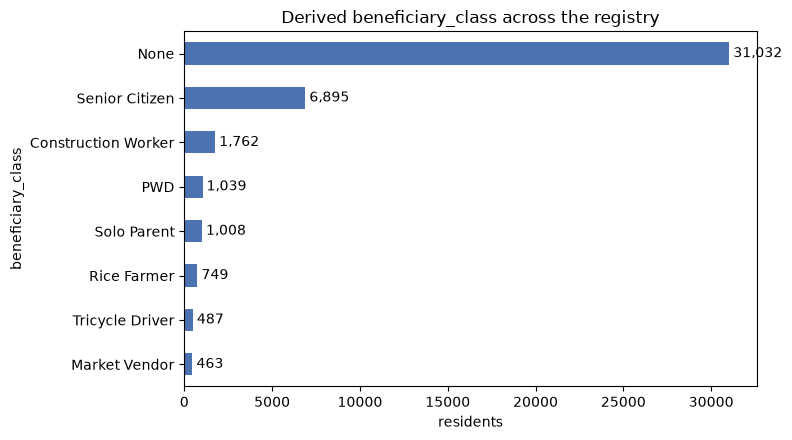

In [8]:
class_counts = df["beneficiary_class"].value_counts(dropna=False).rename(index={np.nan: "(not in any valid class)"})

ax = class_counts.sort_values().plot.barh(color="#4C72B0")
ax.set_xlabel("residents")
ax.set_title("Derived beneficiary_class across the registry")
for i, v in enumerate(class_counts.sort_values()):
    ax.text(v, i, f" {v:,}", va="center")
plt.tight_layout()
plt.show()


## Part 4 — Simulating the one input this file doesn't have

`received_grant_within_3_months` is required by `screen()` but is not
present in `citizen_registry_data.xlsx`. The column below is a **synthetic,
seeded placeholder** used only to exercise the class + grant-history rule at
the registry's real scale/shape — it is not real grant data, and none of
this is written back to the registry.

In [9]:
rng = np.random.default_rng(42)  # seeded for reproducibility

# SIMULATED — not present in source data.
df["sim_received_grant_recently"] = rng.random(len(df)) < 0.10

print(f"simulated 'recent grant' rate: {df['sim_received_grant_recently'].mean() * 100:.1f}%")
df["sim_received_grant_recently"].value_counts()

simulated 'recent grant' rate: 9.9%


sim_received_grant_recently
False    39140
True      4295
Name: count, dtype: int64

## Part 5 — Screen the real registry on class + grant history

Every resident is run through the Part 1 `screen()` with their derived
`beneficiary_class` (Part 3) and the simulated recent-grant flag (Part 4).
Residents who pass both checks are reported as **"Passes screen"**.

In [10]:
def screen_row(row):
    outcome = screen(row["beneficiary_class"], bool(row["sim_received_grant_recently"]))
    return pd.Series({"decision": outcome["decision"], "reason": outcome["reason"]})


df = pd.concat([df, df.apply(screen_row, axis=1)], axis=1)

pass_count = (df["decision"] == "Passes screen").sum()
pass_rate = pass_count / len(df) * 100
print(f"{pass_count:,} / {len(df):,} residents pass class + grant-history screening "
      f"({pass_rate:.1f}%).")
df["decision"].value_counts()

11,145 / 43,435 residents pass class + grant-history screening (25.7%).


decision
Not qualified    32290
Passes screen    11145
Name: count, dtype: int64

## Part 6 — Breakdowns

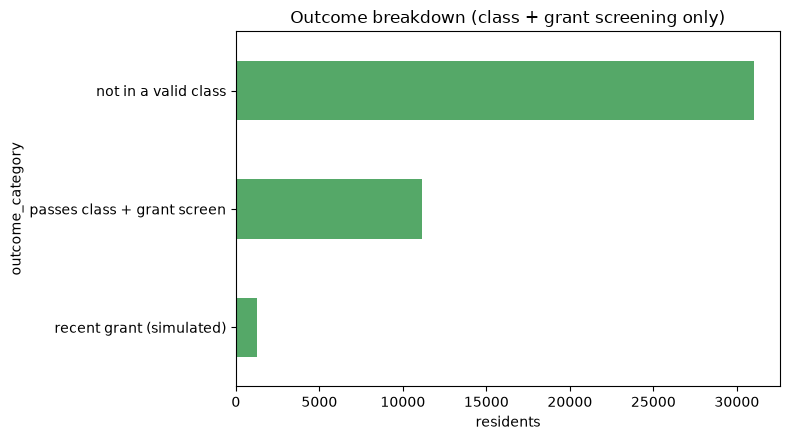

In [11]:
def categorize_outcome(row):
    if row["decision"] == "Passes screen":
        return "passes class + grant screen"
    if row["reason"].startswith("Not a member"):
        return "not in a valid class"
    if row["reason"].startswith("Received a grant"):
        return "recent grant (simulated)"
    return "other"


df["outcome_category"] = df.apply(categorize_outcome, axis=1)

ax = df["outcome_category"].value_counts().sort_values().plot.barh(color="#55A868")
ax.set_xlabel("residents")
ax.set_title("Outcome breakdown (class + grant screening only)")
plt.tight_layout()
plt.show()

In [12]:
by_class = (
    df.assign(passes_screen=df["decision"] == "Passes screen")
    .groupby("beneficiary_class", dropna=False)["passes_screen"]
    .agg(total="size", passes_screen="sum")
    .assign(pass_rate_pct=lambda d: (d["passes_screen"] / d["total"] * 100).round(1))
    .sort_values("total", ascending=False)
)
by_class

,total,passes_screen,pass_rate_pct
beneficiary_class,,,
NaN,31032,0,0.0
Senior Citizen,6895,6179,89.6
Construction Worker,1762,1581,89.7
PWD,1039,942,90.7
Solo Parent,1008,918,91.1
Rice Farmer,749,671,89.6
Tricycle Driver,487,439,90.1
Market Vendor,463,415,89.6


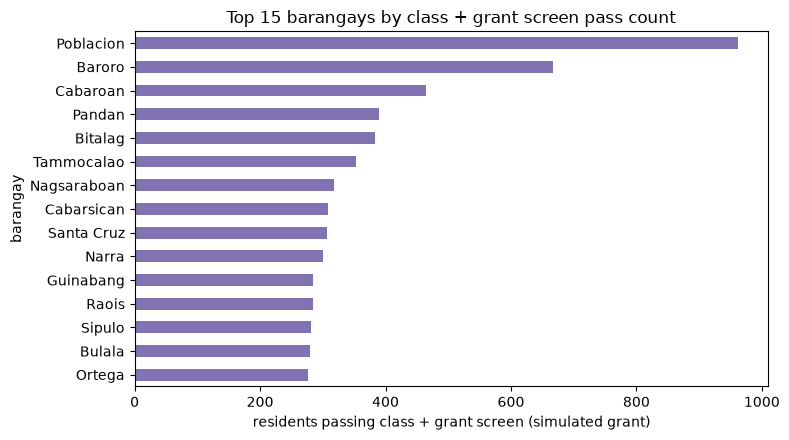

,total,passes_screen,pass_rate_pct
barangay,,,
Poblacion,3719,962,25.9
Baroro,2635,667,25.3
Cabaroan,1916,465,24.3
Pandan,1485,389,26.2
Bitalag,1363,383,28.1
Tammocalao,1443,353,24.5
Nagsaraboan,1115,318,28.5
Cabarsican,1311,309,23.6
Santa Cruz,1278,307,24.0


In [13]:
df["passes_screen"] = df["decision"] == "Passes screen"

barangay_summary = (
    df.groupby("barangay")["passes_screen"]
    .agg(total="size", passes_screen="sum")
    .assign(pass_rate_pct=lambda d: (d["passes_screen"] / d["total"] * 100).round(1))
    .sort_values("passes_screen", ascending=False)
)

top15 = barangay_summary.head(15)
ax = top15["passes_screen"].sort_values().plot.barh(color="#8172B2")
ax.set_xlabel("residents passing class + grant screen (simulated grant)")
ax.set_title("Top 15 barangays by class + grant screen pass count")
plt.tight_layout()
plt.show()

barangay_summary.head(15)

## Part 7 — Export results

In [14]:
output_cols = [
    "citizen_id", "firstname", "middlename", "lastname", "barangay", "age", "psoc",
    "beneficiary_class", "num_matched_classes",
    "sim_received_grant_recently",
    "decision", "reason",
]
out_path = PROJECT_ROOT / "data" / "algo_test_results.xlsx"
df[output_cols].to_excel(out_path, index=False)
print(f"Wrote {len(df):,} rows to {out_path}")
df[output_cols].sample(10, random_state=1)

Wrote 43,435 rows to C:\Users\cisnl\Desktop\sonney_system\beneficiary\data\algo_test_results.xlsx


,citizen_id,firstname,middlename,lastname,barangay,age,psoc,beneficiary_class,num_matched_classes,sim_received_grant_recently,decision,reason
27729,26027730,ROD,SABADO,MANIEDO,Sapilang,21,NaN,None,0,True,Not qualified,Not a member of any valid beneficiary class.
22854,26022855,PERLITA,SALAZAR,BALLON,Santa Rita,65,RETAIL AND WHOLESALE TRADE MANAGERS - RETAIL M...,Senior Citizen,1,False,Passes screen,Passes class and grant-history checks.
13594,26013595,GEMMA,TABLO,LEOVERAS,Nagsaraboan,54,NaN,None,0,False,Not qualified,Not a member of any valid beneficiary class.
36806,26036807,MARICAR,TANO,RODRIGUEZ,Sipulo,49,NaN,None,0,False,Not qualified,Not a member of any valid beneficiary class.
42578,26042579,MICHAEL,CARIASO,MAMARIL,Lisqueb,48,NaN,None,0,False,Not qualified,Not a member of any valid beneficiary class.
9705,26009706,VIDA FAITH,GAÑOLA,CASTRO,Ortega,6,NaN,None,0,False,Not qualified,Not a member of any valid beneficiary class.
23619,26023620,LENNY,ABUNGAN,GAÑOLA,Ortega,28,RESTAURANT MANAGER - RESTAURANT PROPRIETOR,None,0,False,Not qualified,Not a member of any valid beneficiary class.
39851,26039852,MARIBEL,DELMENDO,ORINE,Salincob,21,NaN,None,0,False,Not qualified,Not a member of any valid beneficiary class.
36035,26036036,ROSEMARIE,GIDA,ARQUITOLA,Baroro,44,CASHIERS AND TICKET CLERKS - CASHIER,None,0,False,Not qualified,Not a member of any valid beneficiary class.
32012,26032013,ESTANDIA,MARZAN,ESTIOCO,Baroro,66,NaN,Senior Citizen,1,False,Passes screen,Passes class and grant-history checks.


## Part 8 — Flowchart of the rule-based decision tree

Drawn programmatically from the real `VALID_CLASSES` list (not a static
picture), so the class boxes can never drift out of sync with
`checker/logic.py`. It shows the class → recent-grant rule that Part 5
applies to the registry.

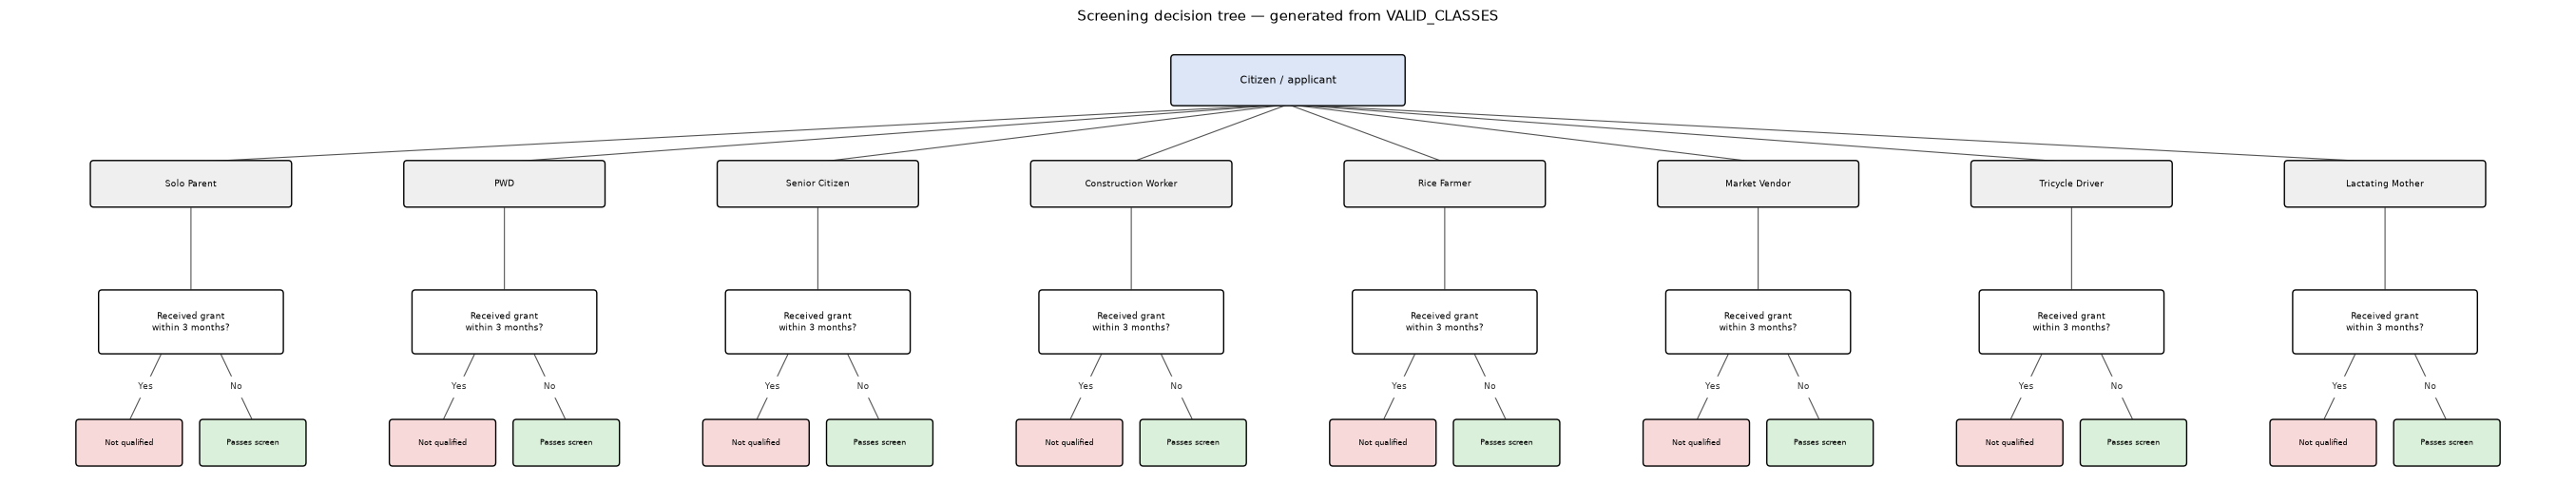

In [15]:
import matplotlib.patches as mpatches

def draw_box(ax, x, y, w, h, text, facecolor="white", fontsize=6.8):
    box = mpatches.FancyBboxPatch(
        (x - w / 2, y - h / 2), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.04",
        linewidth=1, edgecolor="black", facecolor=facecolor, zorder=2,
    )
    ax.add_patch(box)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize, zorder=3)

def draw_arrow(ax, xy0, xy1, label=None):
    ax.annotate("", xy=xy1, xytext=xy0,
                arrowprops=dict(arrowstyle="-", linewidth=0.8, color="#555555"), zorder=1)
    if label:
        mx, my = (xy0[0] + xy1[0]) / 2, (xy0[1] + xy1[1]) / 2
        ax.text(mx, my, label, fontsize=6.2, ha="center", va="center",
                color="#333333", backgroundcolor="white", zorder=3)

n = len(VALID_CLASSES)
col_w = 3.8
xs = [i * col_w for i in range(n)]
root_x = sum(xs) / n

class_h, class_w = 0.5, 2.4
q_h, q_w = 0.7, 2.2
leaf_h, leaf_w = 0.5, 1.25
y_root, y_class, y_grant, y_leaf = 11.4, 10.2, 8.6, 7.2

fig, ax = plt.subplots(figsize=(3.4 * n, 5.4))
draw_box(ax, root_x, y_root, 2.8, 0.55, "Citizen / applicant", facecolor="#DCE6F7", fontsize=8)

grant_label = "Received grant" + chr(10) + "within 3 months?"

for x, cls in zip(xs, VALID_CLASSES):
    draw_box(ax, x, y_class, class_w, class_h, cls, facecolor="#EFEFEF")
    draw_arrow(ax, (root_x, y_root - 0.28), (x, y_class + class_h / 2))

    draw_box(ax, x, y_grant, q_w, q_h, grant_label)
    draw_arrow(ax, (x, y_class - class_h / 2), (x, y_grant + q_h / 2))

    # "Yes" (received a recent grant) -> rejected.
    nq_x = x - 0.75
    draw_box(ax, nq_x, y_leaf, leaf_w, leaf_h, "Not qualified", facecolor="#F7D9D9", fontsize=6.0)
    draw_arrow(ax, (x - 0.35, y_grant - q_h / 2), (nq_x, y_leaf + leaf_h / 2), label="Yes")

    # "No" -> passes the screen.
    pass_x = x + 0.75
    draw_box(ax, pass_x, y_leaf, leaf_w, leaf_h, "Passes screen", facecolor="#DBF0DB", fontsize=6.0)
    draw_arrow(ax, (x + 0.35, y_grant - q_h / 2), (pass_x, y_leaf + leaf_h / 2), label="No")

ax.set_xlim(xs[0] - 2.2, xs[-1] + 2.2)
ax.set_ylim(y_leaf - 0.6, y_root + 0.6)
ax.axis("off")
ax.set_title("Screening decision tree — generated from VALID_CLASSES", fontsize=11)
plt.tight_layout()
plt.show()

## Part 9 — RandomForest performance evaluation

How good is a learned model at recovering the class + grant-history screen
from Part 5? Two passes:

1. **Sanity check** — give a `RandomForestClassifier` the exact features
   the screen uses (`beneficiary_class`, already derived, plus the simulated
   grant flag) and predict `passes_screen`. This target is a noise-free
   deterministic function of those two features, so accuracy near 100% is
   the *correct*, expected result here, not a sign the test is broken.
2. **Realistic test** — don't hand the model the already-derived
   `beneficiary_class`. Instead give it the raw registry fields a real
   intake form would have (age, `pwd`, `solo parent`, occupation-keyword
   flags from `psoc`) plus the simulated grant flag, and ask it to predict
   the same `passes_screen` target. This is the meaningful test: can the
   model reconstruct the class-membership rule from raw fields on its own?

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score, roc_curve,
                              classification_report)

y = df["passes_screen"].map({True: "Qualified", False: "Not qualified"})

### Sanity check: exact features (expected ~100%)

In [17]:
le = LabelEncoder()
beneficiary_class_code = le.fit_transform(df["beneficiary_class"].fillna("None"))
code_lookup = pd.DataFrame({"beneficiary_type": le.classes_, "code": le.transform(le.classes_)})

X_exact = pd.DataFrame({
    "beneficiary_class_code": beneficiary_class_code,
    "received_grant_3mo": df["sim_received_grant_recently"].astype(int),
})

Xtr, Xte, ytr, yte = train_test_split(X_exact, y, test_size=0.2, random_state=42, stratify=y)
exact_rf = RandomForestClassifier(n_estimators=200, random_state=42).fit(Xtr, ytr)
exact_acc = accuracy_score(yte, exact_rf.predict(Xte)) * 100
print(f"Sanity check (exact inputs): accuracy = {exact_acc:.1f}% (expected: ~100%)")
code_lookup

Sanity check (exact inputs): accuracy = 100.0% (expected: ~100%)


,beneficiary_type,code
0,Construction Worker,0
1,Market Vendor,1
2,None,2
3,PWD,3
4,Rice Farmer,4
5,Senior Citizen,5
6,Solo Parent,6
7,Tricycle Driver,7


### Realistic test: self-reported fields, not pre-computed class or true records

`beneficiary_class_code` is replaced by the raw fields it was derived from
(Part 3) — and, since a real intake interview or household survey collects
*self-reported* age, PWD status, solo-parent status, and occupation rather
than perfectly recorded values, each of those is passed through a small
simulated misreport rate before the model ever sees it. The label
(`passes_screen`) still comes from the true, clean values in `df`, so this
measures how well the model holds up against realistic reporting noise —
not a second copy of the rule.

In [18]:
rng3 = np.random.default_rng(11)

# SIMULATED self-report noise on top of the real registry fields — the
# label below still comes from the true (unnoised) values in df.
age_reported = (df["age"] + rng3.normal(0, 2.5, len(df))).round().clip(0, 115)
pwd_reported = (df["pwd"] == "Yes")
pwd_reported = pwd_reported ^ (rng3.random(len(df)) < 0.05)
solo_parent_reported = (df["solo parent"] == "Yes")
solo_parent_reported = solo_parent_reported ^ (rng3.random(len(df)) < 0.05)

raw_features = pd.DataFrame({
    "age_reported": age_reported,
    "pwd_reported_flag": pwd_reported.astype(int),
    "solo_parent_reported_flag": solo_parent_reported.astype(int),
    "received_grant_3mo": df["sim_received_grant_recently"].astype(int),
})

psoc_text = df["psoc"].fillna("")
for cls_name, pattern in PSOC_CLASS_PATTERNS:
    col = "psoc_" + cls_name.lower().replace(" ", "_") + "_reported_flag"
    true_flag = psoc_text.str.contains(pattern)
    misreport = rng3.random(len(df)) < 0.08
    raw_features[col] = (true_flag ^ misreport).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    raw_features, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
qualified_idx = list(clf.classes_).index("Qualified")
y_proba = clf.predict_proba(X_test)[:, qualified_idx]
y_test_bin = (y_test == "Qualified").astype(int)

print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

Not qualified       0.91      0.95      0.93      6458
    Qualified       0.83      0.73      0.78      2229

     accuracy                           0.89      8687
    macro avg       0.87      0.84      0.85      8687
 weighted avg       0.89      0.89      0.89      8687



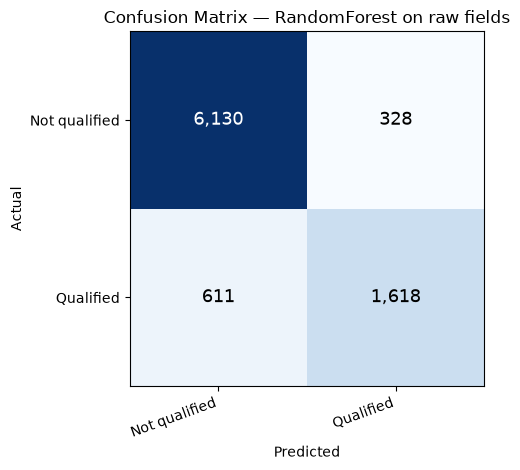

In [19]:
labels_order = ["Not qualified", "Qualified"]
cm = confusion_matrix(y_test, y_pred, labels=labels_order)

fig, ax = plt.subplots(figsize=(5.5, 4.8))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(labels_order, rotation=20, ha="right")
ax.set_yticks([0, 1]); ax.set_yticklabels(labels_order)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — RandomForest on raw fields")
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontsize=13)
plt.tight_layout()
plt.show()

### Model performance metrics

Scores for the self-reported-field model on the held-out 20% test set, with
**Qualified** as the positive class for precision, recall, and F1-score.
ROC-AUC is computed from the model's predicted probability of Qualified.

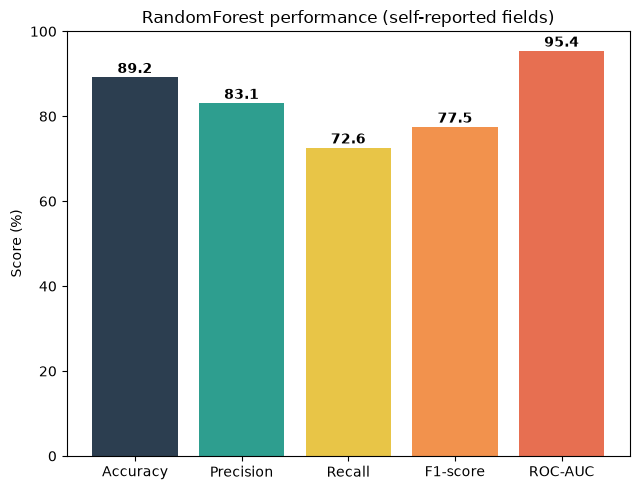

,Score (%)
Metric,
Accuracy,89.2
Precision,83.1
Recall,72.6
F1-score,77.5
ROC-AUC,95.4


In [20]:
performance_metrics = pd.DataFrame(
    {"Score (%)": [
        accuracy_score(y_test, y_pred) * 100,
        precision_score(y_test, y_pred, pos_label="Qualified") * 100,
        recall_score(y_test, y_pred, pos_label="Qualified") * 100,
        f1_score(y_test, y_pred, pos_label="Qualified") * 100,
        roc_auc_score(y_test_bin, y_proba) * 100,
    ]},
    index=pd.Index(["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"], name="Metric"),
).round(1)

scores = performance_metrics["Score (%)"]
colors = ["#2C3E50", "#2E9E8F", "#E8C547", "#F2924D", "#E76F51"]

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.bar(scores.index, scores.values, color=colors)
for i, v in enumerate(scores):
    ax.text(i, v + 1, f"{v:.1f}", ha="center", fontweight="bold")
ax.set_ylim(0, 100)
ax.set_ylabel("Score (%)")
ax.set_title("RandomForest performance (self-reported fields)")
plt.tight_layout()
plt.show()

performance_metrics

### Recall by beneficiary class

Of the test-set residents who truly pass the screen, the share the model also
predicts as Qualified, broken down by their derived `beneficiary_class`.

In [21]:
truly_qualified = y_test == "Qualified"
predicted_qualified = pd.Series(y_pred, index=y_test.index)[truly_qualified] == "Qualified"

recall_by_class = (
    predicted_qualified.groupby(df.loc[predicted_qualified.index, "beneficiary_class"])
    .agg(qualified_in_test="size", predicted_qualified="sum")
    .assign(recall_pct=lambda d: (d["predicted_qualified"] / d["qualified_in_test"] * 100).round(1))
    .sort_values("qualified_in_test", ascending=False)
)
recall_by_class

,qualified_in_test,predicted_qualified,recall_pct
beneficiary_class,,,
Senior Citizen,1221,1170,95.8
Construction Worker,329,224,68.1
Solo Parent,199,96,48.2
PWD,172,76,44.2
Rice Farmer,116,35,30.2
Market Vendor,96,9,9.4
Tricycle Driver,96,8,8.3


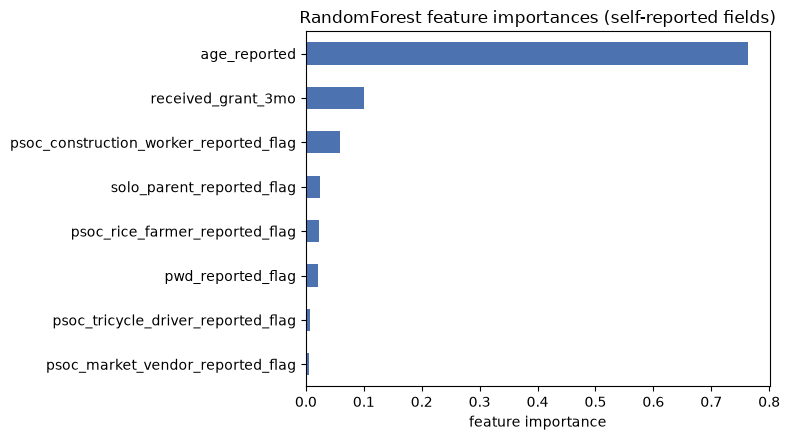

In [22]:
importances = pd.Series(clf.feature_importances_, index=raw_features.columns).sort_values()

ax = importances.plot.barh(color="#4C72B0")
ax.set_xlabel("feature importance")
ax.set_title("RandomForest feature importances (self-reported fields)")
plt.tight_layout()
plt.show()

The self-reported-field RandomForest should score below the sanity check:
it has to recover the priority-ordered class rule (PWD > Solo Parent >
Senior Citizen > occupation keyword) through a small simulated misreport
rate on each underlying field, rather than being handed the exact derived
class. This is a fidelity check on how well a learned model approximates
the rule-based `screen()` under realistic data-quality noise — it is not a
replacement for calling `screen()` itself.

## Summary

- **Part 1** defines the class + grant-history `screen()` (using the real
  `VALID_CLASSES` from `checker/logic.py`) and validates it against
  hand-picked cases — this part has nothing to do with the registry file
  and will keep working as a regression check.
- **Parts 2–3** profile the real ~43,400-resident registry and derive
  `beneficiary_class` from real columns (PWD flag, solo-parent flag, age,
  occupation keywords).
- **Part 4** simulates the recent-grant flag, the one other input
  `screen()` needs that isn't in this export.
- **Part 5** screens every resident on class and grant history, using the
  real `VALID_CLASSES` constant. Residents who pass both are reported as
  "Passes screen".
- **Parts 6–7** break down and export those class + grant-history results.
- **Part 8** is a generated diagram of the class → recent-grant decision
  tree, drawn from the real `VALID_CLASSES` list.
- **Part 9** trains a `RandomForestClassifier` to see how well a learned
  model can recover the Part 5 screen. Given the exact derived class it
  scores ~100% (expected, since the target is a deterministic function of
  that input); given only raw registry fields it has to rediscover the
  class rule itself, which is the more honest read of "how good is this
  model." That model's accuracy, precision, recall, F1-score, and ROC-AUC
  on the held-out test set are reported as a table and chart,
  along with its recall for each beneficiary class.
- To get real (non-simulated) results for the full registry, the simulated
  grant flag would need to be replaced with the actual grant history
  (`records.GrantRecord` / `Beneficiary.prior_grant_date`) already used
  elsewhere in the Django app.